# Indecision in Pairwise-Comparison Learning — Section 3 Experiments

Clean reorganization of `learning-algo/BALD_bt_vs_multiframe_experiment.ipynb`,
focused on a single question: **what is the role of indecision in pairwise-comparison learning?**

### Model recap

We are in the perfectly separable linear-score setting. A query is a pair of options;
the model depends only on the feature difference $\delta = x_{\text{left}} - x_{\text{right}}$.
Given true weights $\omega^\*$ on the simplex,

$$g = \langle \omega^\*, \delta\rangle \quad\text{(directional evidence)},\qquad
   r = \langle \omega^\*, |\delta|\rangle \quad\text{(total evidence)}.$$

The threshold response model adds a noisy margin $\tilde g = g + \varepsilon$ and two forms of indecision:

* **indifference** (low intensity) when $r < \tau_r$,
* **conflict** (high intensity) when $|\tilde g| \le \tau_\kappa\, r$,

otherwise the answer is `LEFT` ($\tilde g>0$) or `RIGHT` ($\tilde g<0$). When
$\tau_r=\tau_\kappa=0$ the model reduces to ordinary logistic Bradley–Terry with slope $1/s$.

### The three experiment blocks

| Block | Question | Headline figure |
|---|---|---|
| **0** | At $\tau_r=\tau_\kappa=0$, does the threshold model reduce to ordinary binary learning? | sanity check |
| **1** | When indecision is *forced* into binary labels, when does binary learning go wrong? | biased forced-choice failure |
| **2** | Even under *benign* forcing, is observing indecision more sample-efficient? | learning curves |

Every learner shares the same hit-and-run MCMC posterior and BALD acquisition; only the
**outcome alphabet / likelihood** differs (4-way broad, 3-way broad, or binary BT). Model
code lives in `indecision_core.py` / `experiments.py`; this notebook only configures runs and plots.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

HERE = os.path.abspath("")
if HERE not in sys.path:
    sys.path.insert(0, HERE)

import indecision_core as ic
import experiments as ex

# ---- plotting style -------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.grid": True, "grid.alpha": 0.25,
})

PALETTE = {
    "broad4":   "#4c1d95",  # deep purple  -- broad 4-way (the ceiling)
    "broad3":   "#7c3aed",  # purple       -- broad 3-way
    "bt_skip":  "#0ea5e9",  # blue         -- ignore indecision
    "bt_5050":  "#10b981",  # green        -- benign 50/50
    "bt_btcons":"#059669",  # dark green   -- benign BT-consistent
    "bt_lex":   "#f59e0b",  # amber        -- biased lexicographic (feature-keyed)
    "bt_single":"#ef4444",  # red          -- biased single-feature (feature-keyed)
    "bt_self":  "#b91c1c",  # dark red     -- biased self-similarity (feature-keyed)
    "bt_gut":   "#7f1d1d",  # darkest red  -- biased gut-weights (feature-keyed, dense)
    "bt_comp":  "#64748b",  # slate        -- structural: compromise / extremeness aversion
}
NAMES = {
    "broad4": "Broad (4-way)", "broad3": "Broad (3-way)",
    "bt_skip": "Binary: ignore indecision", "bt_5050": "Binary: forced 50/50",
    "bt_btcons": "Binary: forced BT-consistent", "bt_lex": "Binary: forced lexicographic",
    "bt_single": "Binary: forced single-feature", "bt_self": "Binary: forced self-similarity",
    "bt_gut": "Binary: forced gut-weights", "bt_comp": "Binary: forced compromise",
}

# ---- global simulation configuration -------------------------------------
# PILOT scale runs end-to-end in a couple of minutes. Scale up (N_ORACLES, T,
# N_SAMPLES) for the paper-quality run; the seeds and structure are unchanged.
DIM         = ic.DIM
NOISE_SCALE = 0.5
NOISE_TYPE  = "logistic"
N_ORACLES   = 40        # oracles == trials; more -> tighter error bars
ORACLE_ALPHA= 0.3        # sparse/peaky oracles (harder; room to improve)
N_SAMPLES   = 150
BURN_IN     = 80
N_CAND      = 30
N_HOLDOUT   = 400
N_JOBS      = -1         # joblib trials in parallel; set 1 to debug
TAU_R, TAU_K = 0.25, 0.25  # operating point for Blocks 1 & 2

ORACLES = ex.make_oracles(N_ORACLES, dim=DIM, seed=2026, alpha=ORACLE_ALPHA)
print(f"{N_ORACLES} oracles, dim={DIM}, noise={NOISE_TYPE}(s={NOISE_SCALE})")
print(f"feature names: {ic.FEATURE_NAMES}")

# ---- seed policy: common random numbers (CRN) ----------------------------
# run_method() derives per-trial seeds for the candidate pool, oracle noise,
# holdout, and regret slates from the *trial index only*, so every method sees
# identical conditions on a given trial. The MCMC seed is base_seed + trial.
# We pass the SAME base_seed to every method, so methods are compared paired
# (they differ only in their own logic, not in their randomness). In particular,
# at tau=0 the broad and binary learners then produce *identical* curves.
SEED = 2027

# Worst-case downstream regret = the anti-optimal policy that always picks the item
# the TRUE rule ranks lowest. Per slate that equals the spread (max-min) of true
# scores; we average it per oracle and use it to report regret as a % of this ceiling
# (it is NOT 1.0 -- it depends on how spread the true scores are).
def worstcase_regret(omega_star, seed, n_slates=4000, slate_size=5, cov=None, scale=None):
    rng = np.random.default_rng(seed)
    items = ic.draw_features(n_slates * slate_size, DIM, rng, cov, scale).reshape(n_slates, slate_size, DIM)
    t = items @ omega_star
    return float(np.mean(t.max(1) - t.min(1)))

def regret_ceiling(oracles, cov=None, scale=None):
    return float(np.mean([worstcase_regret(w, 600_000 + i, cov=cov, scale=scale)
                          for i, w in enumerate(oracles)]))


40 oracles, dim=5, noise=logistic(s=0.5)
feature names: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']


## Block 0 — Reduction theorem (sanity check)

**Claim.** At $\tau_r=\tau_\kappa=0$ there is never an indifferent or conflicted response, and the
4-outcome likelihood collapses *exactly* to logistic Bradley–Terry with slope $1/s$
(verified algebraically in `indecision_core.response_probs`). So the broad-response learner and
the ordinary binary learner should behave essentially identically.

We run both at $\tau_r=\tau_\kappa=0$ under **common random numbers** (same oracle, candidates, and
inference seed). Because the likelihoods are equal, the two learners see identical data and produce
**bit-for-bit identical** weight-error curves — the strongest form of the sanity check (we assert
the max curve difference is numerically zero). The binary curve is drawn dashed with markers, on top
of the broad curve, so you can see the two coincide exactly.

In [2]:
T0 = 50
cfg0 = dict(tau_r=0.0, tau_kappa=0.0, noise_scale=NOISE_SCALE, noise_type=NOISE_TYPE,
            T=T0, n_candidates=N_CAND, n_samples=N_SAMPLES, burn_in=BURN_IN,
            n_holdout=N_HOLDOUT, n_jobs=N_JOBS)

t0 = time.time()
# Same base_seed for both -> common random numbers -> identical curves at tau=0.
b0 = {
    "broad4":  ex.run_method({"kind": "broad", "n_outcomes": 4}, ORACLES, base_seed=SEED, **cfg0),
    "bt_skip": ex.run_method({"kind": "bt"},                     ORACLES, base_seed=SEED, **cfg0),
}
print(f"Block 0 done in {time.time()-t0:.1f}s")

c_b = ex.aggregate_curve(b0["broad4"], "l1s")["mean"]
c_t = ex.aggregate_curve(b0["bt_skip"], "l1s")["mean"]
maxdiff = float(np.abs(c_b - c_t).max())
print(f"max |broad - binary| over the L1 curve = {maxdiff:.2e}")
assert maxdiff < 1e-9, "reduction is exact at tau=0: curves must be identical"


Block 0 done in 14.6s
max |broad - binary| over the L1 curve = 0.00e+00


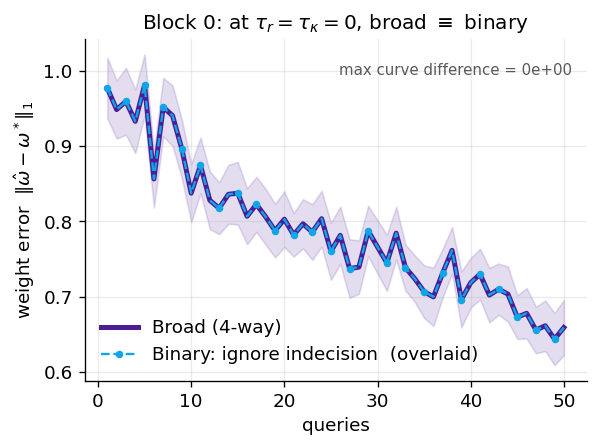

The dashed binary curve lies exactly on the broad curve (max difference 0e+00) -> the threshold model reduces to ordinary binary learning when there is no indecision.


In [3]:
fig, ax = plt.subplots(figsize=(5.4, 3.7))
x = np.arange(1, T0 + 1)
agg_b = ex.aggregate_curve(b0["broad4"], "l1s")
agg_t = ex.aggregate_curve(b0["bt_skip"], "l1s")
ax.fill_between(x, agg_b["mean"] - agg_b["stderr"], agg_b["mean"] + agg_b["stderr"],
                color=PALETTE["broad4"], alpha=0.15)
ax.plot(x, agg_b["mean"], color=PALETTE["broad4"], lw=3, label=NAMES["broad4"])
ax.plot(x, agg_t["mean"], color=PALETTE["bt_skip"], lw=1.4, ls="--", marker="o", ms=3.5,
        markevery=2, label=NAMES["bt_skip"] + "  (overlaid)")
ax.set_xlabel("queries"); ax.set_ylabel(r"weight error  $\|\hat\omega-\omega^*\|_1$")
ax.set_title(r"Block 0: at $\tau_r=\tau_\kappa=0$, broad $\equiv$ binary")
ax.text(0.97, 0.93, f"max curve difference = {maxdiff:.0e}", transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color="0.35")
ax.legend(loc="lower left")
fig.savefig("fig_block0_sanity.pdf"); fig.savefig("fig_block0_sanity.png")
plt.show()
print("The dashed binary curve lies exactly on the broad curve (max difference "
      f"{maxdiff:.0e}) -> the threshold model reduces to ordinary binary learning when "
      "there is no indecision.")


## Block 1 — Forcing indecision into binary labels

Now $\tau_r,\tau_\kappa>0$, so the respondent is sometimes internally indecisive, but the interface
forces a `LEFT`/`RIGHT` choice. We feed a **binary** learner the forced labels under different
behavioral assumptions about *how* people resolve indecision:

* **Benign** — `50/50` (unbiased coin) and `BT-consistent` (choose `LEFT` w.p. $\sigma(g/s)$);
* **Feature-keyed biased** — `lexicographic` (follow a feature ranking), `single-feature` (always
  follow one feature), `similarity-to-self` (closer to a fixed self-vector), and `gut-weights`
  (defer to a *different* weight vector $\omega_{\text{bias}}$ — the dual-process "System-1" heuristic;
  this generalizes single-feature and lexicographic to a dense pull);
* **Structural** — `compromise` (extremeness aversion: pick the less extreme option). Included to test
  a *non*-feature-keyed heuristic.

Each *feature-keyed* rule injects a signal aligned with the feature differences on the indecisive
queries (where $g\approx0$), which the binary learner misattributes to $\omega$. The structural rule
does not align with any feature axis — a useful contrast, since it turns out to be far less damaging.

**Isolating the forcing effect.** Any binary learner is mildly misspecified here (decisive responses
come from the threshold model, not pure Bradley–Terry), which produces a small distortion *shared by
every* binary method — even the one that simply ignores indecision. To show the effect of the
*behavior*, we plot **forcing-induced distortion** $\hat\omega(\text{rule})-\hat\omega(\text{ignore})$,
paired per oracle, which cancels that shared drift. We also report **downstream best-of-$N$ regret**
under the true $\omega^\*$ and final weight error (absolute) in the table.

The feature-keyed rules are deliberately pointed at *different* features so the distortion is visibly
rule-specific: single-feature/self → `elderlyDep` (feature 0), lexicographic → `lifeYearsGained`
(feature 1), gut-weights → mostly `obesity` (feature 2). The structural `compromise` rule keys on no
feature axis.

In [4]:
T1 = 130
SELF_VEC = np.eye(DIM)[0]               # 'self' favors feature 0 (elderlyDep)
GUT_WEIGHTS = np.array([0.1, 0.1, 0.5, 0.2, 0.1])  # System-1 'gut' fixates on obesity (feature 2)
cfg1 = dict(tau_r=TAU_R, tau_kappa=TAU_K, noise_scale=NOISE_SCALE, noise_type=NOISE_TYPE,
            T=T1, n_candidates=N_CAND, n_samples=N_SAMPLES, burn_in=BURN_IN,
            n_holdout=N_HOLDOUT, n_jobs=N_JOBS)

SPECS1 = {  # ordered: benign, then feature-keyed biased, then structural
    "bt_5050":  {"kind": "bt", "forcing": ic.force_5050},
    "bt_btcons":{"kind": "bt", "forcing": ic.force_bt_consistent},
    "bt_lex":   {"kind": "bt", "forcing": ic.force_lex,
                 "forcing_kwargs": {"ranking": [1, 3, 0, 2, 4]}},
    "bt_single":{"kind": "bt", "forcing": ic.force_single_feature,
                 "forcing_kwargs": {"feature": 0}},
    "bt_self":  {"kind": "bt", "forcing": ic.force_self_similarity,
                 "forcing_kwargs": {"self_vec": SELF_VEC}},
    "bt_gut":   {"kind": "bt", "forcing": ic.force_gut_weights,
                 "forcing_kwargs": {"omega_bias": GUT_WEIGHTS}},
    "bt_comp":  {"kind": "bt", "forcing": ic.force_compromise},
}
BENIGN = ["bt_5050", "bt_btcons"]
STRUCTURAL = ["bt_comp"]   # non-feature-keyed; reported separately from the feature-keyed biased rules

t0 = time.time()
# Common random numbers: every rule and the baseline share base_seed=SEED, so the
# forcing-induced distortion below reflects only the forcing behavior, not MCMC noise.
b1 = {k: ex.run_method(s, ORACLES, base_seed=SEED, **cfg1) for k, s in SPECS1.items()}
# No-forcing baseline (ignore indecision) -> reference for forcing-induced distortion.
b1_skip = ex.run_method({"kind": "bt"}, ORACLES, base_seed=SEED, **cfg1)
print(f"Block 1 done in {time.time()-t0:.1f}s")

WC = regret_ceiling(ORACLES)   # anti-optimal regret ceiling for this oracle set
print(f"worst-case (anti-optimal) regret ceiling = {WC:.3f}\n")

print(f"{'forcing rule':<28}{'L1':>8}{'cos':>8}{'regret %worst':>14}{'pair err':>10}")
for k in SPECS1:
    L1 = ex.aggregate_scalar(b1[k], 'l1_final')['mean']
    cs = ex.aggregate_scalar(b1[k], 'cos_final')['mean']
    bo = ex.aggregate_scalar(b1[k], 'best_of_n_regret')['mean']
    pe = ex.aggregate_scalar(b1[k], 'pairwise_regret')['mean']
    tag = "benign" if k in BENIGN else ("structural" if k in STRUCTURAL else "biased")
    print(f"{NAMES[k]:<28}{L1:>8.3f}{cs:>8.3f}{100*bo/WC:>13.0f}%{pe:>10.3f}   [{tag}]")


Block 1 done in 110.7s
worst-case (anti-optimal) regret ceiling = 0.463

forcing rule                      L1     cos regret %worst  pair err
Binary: forced 50/50           0.442   0.934            3%     0.102   [benign]
Binary: forced BT-consistent   0.377   0.954            2%     0.085   [benign]
Binary: forced lexicographic   0.539   0.904            5%     0.130   [biased]
Binary: forced single-feature   0.496   0.907            5%     0.127   [biased]
Binary: forced self-similarity   0.483   0.920            4%     0.117   [biased]
Binary: forced gut-weights     0.535   0.901            5%     0.128   [biased]
Binary: forced compromise      0.439   0.935            3%     0.104   [structural]


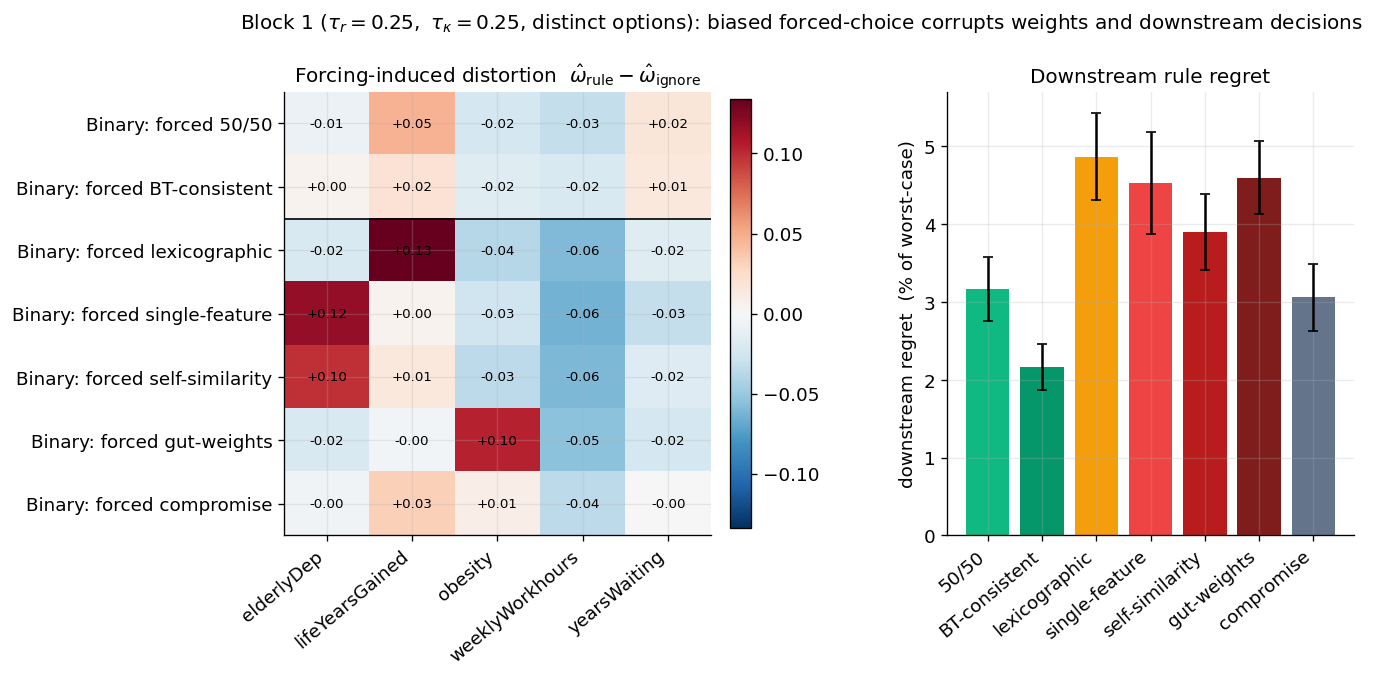

Benign rules (above the line) leave ω essentially undistorted; biased rules push weight onto the feature they key on and pay for it in downstream regret.


In [5]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 4.8),
                                gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.45})

# Panel A: forcing-induced distortion heatmap (rules x features), relative to ignoring.
keys1 = list(SPECS1.keys())
D = np.array([ex.relative_distortion(b1[k], b1_skip)["mean"] for k in keys1])  # (n_rules, DIM)
vmax = np.abs(D).max()
im = axA.imshow(D, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
axA.set_xticks(range(DIM)); axA.set_xticklabels(ic.FEATURE_NAMES, rotation=40, ha="right")
axA.set_yticks(range(len(keys1))); axA.set_yticklabels([NAMES[k] for k in keys1])
axA.set_title(r"Forcing-induced distortion  $\hat\omega_{\rm rule}-\hat\omega_{\rm ignore}$")
for i in range(len(keys1)):
    for j in range(DIM):
        axA.text(j, i, f"{D[i,j]:+.02f}", ha="center", va="center",
                 fontsize=8, color="black")
axA.axhline(len(BENIGN) - 0.5, color="k", lw=1.0)  # benign | biased divider
fig.colorbar(im, ax=axA, fraction=0.046, pad=0.04)

# Panel B: downstream best-of-N regret per rule, as % of the anti-optimal ceiling.
bo  = [100 * ex.aggregate_scalar(b1[k], 'best_of_n_regret')['mean']  / WC for k in keys1]
boe = [100 * ex.aggregate_scalar(b1[k], 'best_of_n_regret')['stderr'] / WC for k in keys1]
colors = [PALETTE[k] for k in keys1]
axB.bar(range(len(keys1)), bo, yerr=boe, color=colors, capsize=3)
axB.set_xticks(range(len(keys1)))
axB.set_xticklabels([NAMES[k].replace("Binary: forced ", "") for k in keys1],
                    rotation=40, ha="right")
axB.set_ylabel("downstream regret  (% of worst-case)")
axB.set_title("Downstream rule regret")

fig.suptitle(r"Block 1 ($\tau_r=%.2f,\ \tau_\kappa=%.2f$, distinct options): "
             "biased forced-choice corrupts weights and downstream decisions" % (TAU_R, TAU_K),
             y=1.02, fontsize=12)
fig.savefig("fig_block1_bias.pdf"); fig.savefig("fig_block1_bias.png")
plt.show()
print("Benign rules (above the line) leave ω essentially undistorted; biased rules push weight "
      "onto the feature they key on and pay for it in downstream regret.")


## Block 2 — Even benign forcing wastes information

Grant the binary learner the most favorable case: when the respondent is indecisive they answer
**benignly** (unbiased `50/50`), so binary learning is not asymptotically wrong. We compare, per
unit of **query budget** (every elicited query costs the same regardless of the answer):

* **Binary, ignore indecision** — drops indecisive responses;
* **Binary, forced 50/50** — benign forced labels;
* **Broad (3-way)** — observes `{LEFT, RIGHT, UNKNOWN}`;
* **Broad (4-way)** — observes `{LEFT, RIGHT, INDIFFERENT, CONFLICT}`.

Indifference constrains $r=\langle\omega,|\delta|\rangle$ and conflict constrains $|g|$ in ways
binary labels cannot, so the broad learners should reach a given weight error with fewer queries.

In [6]:
T2 = 60
cfg2 = dict(tau_r=TAU_R, tau_kappa=TAU_K, noise_scale=NOISE_SCALE, noise_type=NOISE_TYPE,
            T=T2, n_candidates=N_CAND, n_samples=N_SAMPLES, burn_in=BURN_IN,
            n_holdout=N_HOLDOUT, n_jobs=N_JOBS)

SPECS2 = {
    "bt_skip": {"kind": "bt"},
    "bt_5050": {"kind": "bt", "forcing": ic.force_5050},
    "broad3":  {"kind": "broad", "n_outcomes": 3},
    "broad4":  {"kind": "broad", "n_outcomes": 4},
}
t0 = time.time()
# Common random numbers: all learners share base_seed=SEED, so the curves are paired
# per oracle (they differ only in outcome alphabet / forcing, not in randomness).
b2 = {k: ex.run_method(s, ORACLES, base_seed=SEED, **cfg2) for k, s in SPECS2.items()}
print(f"Block 2 done in {time.time()-t0:.1f}s")


Block 2 done in 32.3s


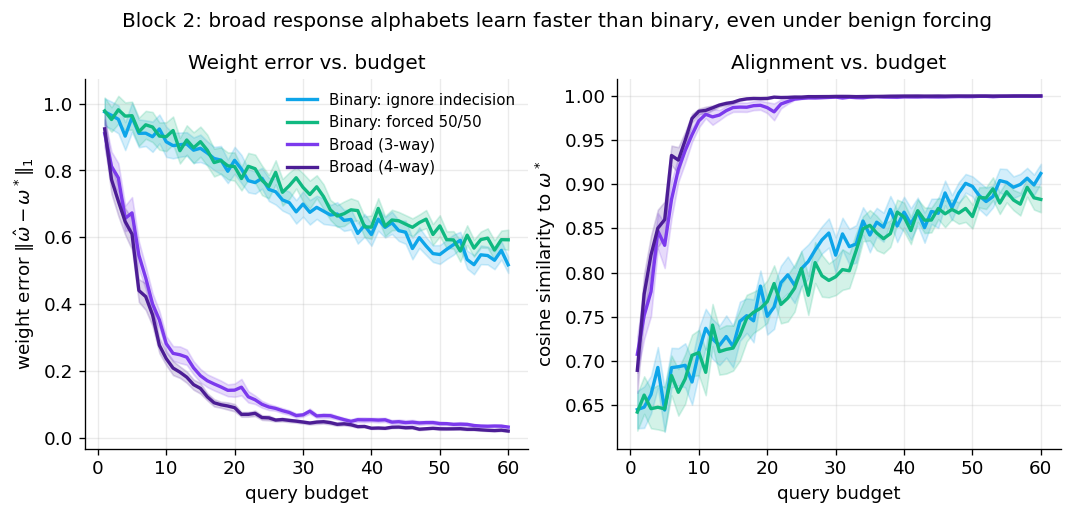

queries to reach L1 <= 0.3:
  Binary: ignore indecision       > 60
  Binary: forced 50/50            > 60
  Broad (3-way)                     10
  Broad (4-way)                      9


In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.5, 4.0))
x = np.arange(1, T2 + 1)
for key in SPECS2:
    aL = ex.aggregate_curve(b2[key], "l1s")
    axL.plot(x, aL["mean"], color=PALETTE[key], lw=2, label=NAMES[key])
    axL.fill_between(x, aL["mean"]-aL["stderr"], aL["mean"]+aL["stderr"],
                     color=PALETTE[key], alpha=0.18)
    aC = ex.aggregate_curve(b2[key], "cos_sims")
    axR.plot(x, aC["mean"], color=PALETTE[key], lw=2, label=NAMES[key])
    axR.fill_between(x, aC["mean"]-aC["stderr"], aC["mean"]+aC["stderr"],
                     color=PALETTE[key], alpha=0.18)
axL.set_xlabel("query budget"); axL.set_ylabel(r"weight error $\|\hat\omega-\omega^*\|_1$")
axL.set_title("Weight error vs. budget"); axL.legend(fontsize=9)
axR.set_xlabel("query budget"); axR.set_ylabel(r"cosine similarity to $\omega^*$")
axR.set_title("Alignment vs. budget")
fig.suptitle("Block 2: broad response alphabets learn faster than binary, even under benign forcing",
             y=1.02, fontsize=12)
fig.savefig("fig_block2_efficiency.pdf"); fig.savefig("fig_block2_efficiency.png")
plt.show()

# Budget to reach a target weight error.
TARGET = 0.30
print(f"queries to reach L1 <= {TARGET}:")
for key in SPECS2:
    m = ex.aggregate_curve(b2[key], "l1s")["mean"]
    hit = np.where(m <= TARGET)[0]
    print(f"  {NAMES[key]:<30}{('%d' % (hit[0]+1)) if len(hit) else '> %d' % T2:>6}")


## Severe-indecision regime — when indecision dominates

Blocks 1–2 compared **clearly-distinct** options ($x_{\text{left}},x_{\text{right}}$ independent),
so most responses are decisive and the BALD learner can lean on genuine choices — biased forcing only
mildly distorts $\omega$. That is the benign end. But real elicitation often compares **similar**
options: people hesitate precisely when the alternatives are alike. We change *one thing* and keep
everything else identical to Blocks 1–2 (same oracles, same $\tau$, same five rules):

> **Similar options** — $x_{\text{right}} = x_{\text{left}} + \mathcal{N}(0,\sigma)$, $\sigma=0.3$.

Smaller feature differences mean smaller total evidence $r$, so the respondent is *indecisive most of
the time*, and the binary learner's labels are now dominated by the forcing rule rather than genuine
preference. Nothing is rigged against the respondent — the weights are ordinary and the tiebreaker is
**orthogonal** to true preference, not opposed to it.

**The failure mode is feature inflation.** When indecisive, $g\approx0$ (the options truly are a
toss-up by the respondent's values), so the forced label carries no preference signal — only whatever
feature the tiebreaker keys on. The binary learner has no way to know, so it *inflates the weight of
that feature*: a rule that always defers to one attribute makes the learner believe that attribute
matters far more than it does. We show the learned-vs-true weight on the keyed feature below to make
this concrete. Benign forcing and broad learning are unaffected; biased forcing roughly triples
downstream regret.

In [8]:
# ---- severe regime: SAME oracles / tau / rules as Blocks 1-2, only options are SIMILAR ----
QUERY_SIGMA = 0.30
cfgS = dict(tau_r=TAU_R, tau_kappa=TAU_K, noise_scale=NOISE_SCALE, noise_type=NOISE_TYPE,
            T=90, n_candidates=N_CAND, n_samples=N_SAMPLES, burn_in=BURN_IN,
            n_holdout=N_HOLDOUT, n_jobs=N_JOBS, query_sigma=QUERY_SIGMA)
T_SEV = cfgS["T"]

# indecision is now the norm, not the exception:
_rr = np.random.default_rng(0); _cnt = {"left":0,"right":0,"indifferent":0,"conflict":0}
for w in ORACLES:
    for q in ic.sample_queries(150, DIM, _rr, similarity=QUERY_SIGMA):
        _cnt[ic.sample_response(q, w, TAU_R, TAU_K, NOISE_SCALE, NOISE_TYPE, _rr)] += 1
_tot = sum(_cnt.values())
print(f"with similar options: {100*(_cnt['left']+_cnt['right'])/_tot:.0f}% decisive "
      f"(vs ~57% for distinct options) -> indecision dominates")

SPECS_S = dict(SPECS1)                       # exact same forcing rules as Block 1
SPECS_S["broad3"] = {"kind": "broad", "n_outcomes": 3}
SPECS_S["broad4"] = {"kind": "broad", "n_outcomes": 4}

t0 = time.time()
bS = {k: ex.run_method(s, ORACLES, base_seed=SEED, **cfgS) for k, s in SPECS_S.items()}
bS_skip = ex.run_method({"kind": "bt"}, ORACLES, base_seed=SEED, **cfgS)
print(f"Severe regime done in {time.time()-t0:.1f}s   (worst-case ceiling = {WC:.3f})\n")

# Feature inflation: learned vs true weight on each biased rule's keyed feature.
KEYED = {"bt_lex": 1, "bt_single": 0, "bt_self": 0, "bt_gut": 2}  # feature each rule defers to
RULES_S = ["bt_5050", "bt_btcons", "bt_lex", "bt_single", "bt_self", "bt_gut", "bt_comp"]
print(f"{'forcing rule':<28}{'L1':>7}{'% worst':>9}   feature inflation (true -> learned)")
for k in RULES_S:
    L1 = ex.aggregate_scalar(bS[k], 'l1_final')['mean']
    bo = ex.aggregate_scalar(bS[k], 'best_of_n_regret')['mean']
    tag = "benign" if k in BENIGN else ("structural" if k in STRUCTURAL else "biased")
    extra = ""
    if k in KEYED:
        j = KEYED[k]
        tw = float(np.mean([w[j] for w in ORACLES]))
        lw = float(np.mean([t['omega_hat'][j] for t in bS[k]]))
        extra = f"   {ic.FEATURE_NAMES[j]}: {tw:.2f} -> {lw:.2f}"
    print(f"{NAMES[k]:<28}{L1:>7.2f}{100*bo/WC:>8.0f}%   [{tag}]{extra}")


with similar options: 25% decisive (vs ~57% for distinct options) -> indecision dominates


Severe regime done in 125.7s   (worst-case ceiling = 0.463)

forcing rule                     L1  % worst   feature inflation (true -> learned)
Binary: forced 50/50           0.66       8%   [benign]
Binary: forced BT-consistent   0.63       7%   [benign]
Binary: forced lexicographic   0.95      18%   [biased]   lifeYearsGained: 0.12 -> 0.44
Binary: forced single-feature   0.89      17%   [biased]   elderlyDep: 0.20 -> 0.49
Binary: forced self-similarity   0.86      15%   [biased]   elderlyDep: 0.20 -> 0.47
Binary: forced gut-weights     0.92      17%   [biased]   obesity: 0.21 -> 0.42
Binary: forced compromise      0.69       9%   [structural]


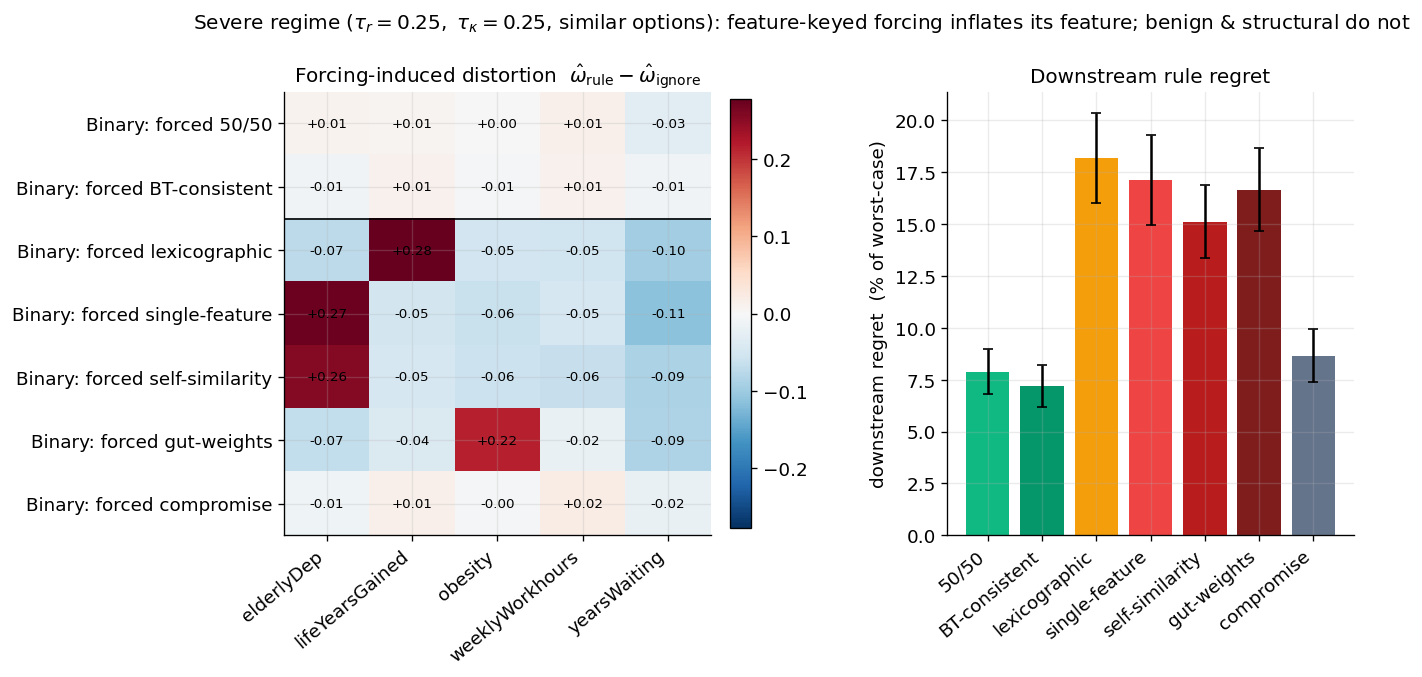

Same oracles/thresholds/rules as Block 1 -- only the options are now similar. Feature-keyed rules (lex/single/self/gut) inflate their feature and pay large regret; the structural compromise rule, whose signal is ~orthogonal to feature differences, stays near benign.


In [9]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 4.8),
                                gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.45})
keysS = RULES_S

# Panel A: forcing-induced distortion, relative to ignoring (cancels shared misspec drift).
D = np.array([ex.relative_distortion(bS[k], bS_skip)["mean"] for k in keysS])
vmax = np.abs(D).max()
im = axA.imshow(D, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
axA.set_xticks(range(DIM)); axA.set_xticklabels(ic.FEATURE_NAMES, rotation=40, ha="right")
axA.set_yticks(range(len(keysS))); axA.set_yticklabels([NAMES[k] for k in keysS])
axA.set_title(r"Forcing-induced distortion  $\hat\omega_{\rm rule}-\hat\omega_{\rm ignore}$")
for i in range(len(keysS)):
    for j in range(DIM):
        axA.text(j, i, f"{D[i,j]:+.02f}", ha="center", va="center", fontsize=8)
axA.axhline(len(BENIGN) - 0.5, color="k", lw=1.0)  # benign | biased divider
fig.colorbar(im, ax=axA, fraction=0.046, pad=0.04)

# Panel B: downstream regret as % of the anti-optimal ceiling.
bo  = [100 * ex.aggregate_scalar(bS[k], 'best_of_n_regret')['mean']  / WC for k in keysS]
boe = [100 * ex.aggregate_scalar(bS[k], 'best_of_n_regret')['stderr'] / WC for k in keysS]
axB.bar(range(len(keysS)), bo, yerr=boe, color=[PALETTE[k] for k in keysS], capsize=3)
axB.set_xticks(range(len(keysS)))
axB.set_xticklabels([NAMES[k].replace("Binary: forced ", "") for k in keysS], rotation=40, ha="right")
axB.set_ylabel("downstream regret  (% of worst-case)")
axB.set_title("Downstream rule regret")

fig.suptitle(r"Severe regime ($\tau_r=%.2f,\ \tau_\kappa=%.2f$, similar options): "
             "feature-keyed forcing inflates its feature; benign & structural do not" % (TAU_R, TAU_K),
             y=1.02, fontsize=12)
fig.savefig("fig_severe_bias.pdf"); fig.savefig("fig_severe_bias.png")
plt.show()
print("Same oracles/thresholds/rules as Block 1 -- only the options are now similar. Feature-keyed "
      "rules (lex/single/self/gut) inflate their feature and pay large regret; the structural "
      "compromise rule, whose signal is ~orthogonal to feature differences, stays near benign.")


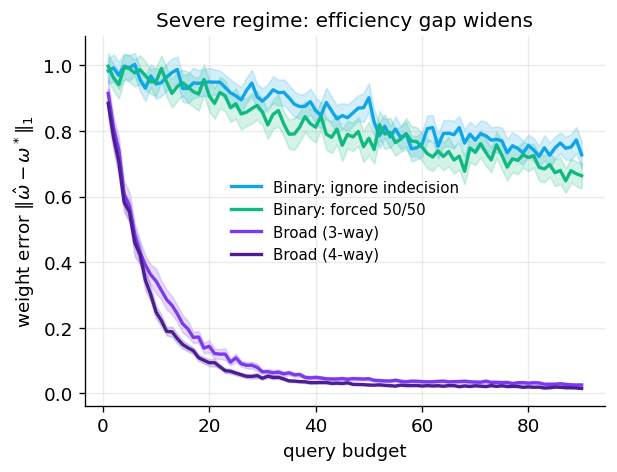

In [10]:
fig, ax = plt.subplots(figsize=(5.6, 4.0))
x = np.arange(1, T_SEV + 1)
for key in ["bt_skip_S", "bt_5050", "broad3", "broad4"]:
    src = bS_skip if key == "bt_skip_S" else bS[key]
    name = NAMES["bt_skip"] if key == "bt_skip_S" else NAMES[key]
    col  = PALETTE["bt_skip"] if key == "bt_skip_S" else PALETTE[key]
    agg = ex.aggregate_curve(src, "l1s")
    ax.plot(x, agg["mean"], color=col, lw=2, label=name)
    ax.fill_between(x, agg["mean"]-agg["stderr"], agg["mean"]+agg["stderr"], color=col, alpha=0.18)
ax.set_xlabel("query budget"); ax.set_ylabel(r"weight error $\|\hat\omega-\omega^*\|_1$")
ax.set_title("Severe regime: efficiency gap widens")
ax.legend(fontsize=9)
fig.savefig("fig_severe_efficiency.pdf"); fig.savefig("fig_severe_efficiency.png")
plt.show()


## Appendix — Robustness / sensitivity

Are the conclusions artifacts of *our* choices for the oracle distribution (sparse Dirichlet $\alpha$)
and the feature/query distribution (i.i.d. $U[0,1]$ options)? We vary both and re-check the three
structural claims: **(i)** reduction at $\tau=0$, **(ii)** broad $\gg$ binary, **(iii)** benign $<$
biased. The feature-model sweep includes a row built from the **real kidney elicitation options** —
the empirical per-attribute scales and 5×5 correlation read straight from
`kidneystudy/kidney_features_raw.csv` — so the bias effect size is reported at the geometry actually
observed, not just at independence or an arbitrary $\rho$. These sweeps use a smaller oracle count and
budget than the main blocks — we only need the qualitative ordering, not publication-precision error
bars. Regret is reported as % of the per-setting worst-case ceiling.

In [11]:
# ---- A. Oracle concentration (alpha) x query distribution ----
APP_N, APP_T = 12, 60
appcfg = dict(noise_scale=NOISE_SCALE, noise_type=NOISE_TYPE, T=APP_T, n_candidates=N_CAND,
              n_samples=100, burn_in=50, n_holdout=350, n_jobs=N_JOBS)
APP_METHODS = {
    "50/50":      {"kind": "bt", "forcing": ic.force_5050},
    "single":     {"kind": "bt", "forcing": ic.force_single_feature, "forcing_kwargs": {"feature": 0}},
    "gut":        {"kind": "bt", "forcing": ic.force_gut_weights, "forcing_kwargs": {"omega_bias": GUT_WEIGHTS}},
    "compromise": {"kind": "bt", "forcing": ic.force_compromise},
    "broad4":     {"kind": "broad", "n_outcomes": 4},
}
print("A. regret (% of worst-case) by oracle concentration x query distribution:\n")
print(f"{'alpha':>5} {'query':<9} | " + " ".join(f"{m:>10}" for m in APP_METHODS))
for alpha in [0.1, 0.3, 1.0]:
    Oa = ex.make_oracles(APP_N, dim=DIM, seed=2026, alpha=alpha)
    W = regret_ceiling(Oa)
    for qlabel, sig in [("distinct", None), ("similar", 0.30)]:
        cells = []
        for m, sp in APP_METHODS.items():
            r = ex.run_method(sp, Oa, base_seed=SEED, tau_r=TAU_R, tau_kappa=TAU_K,
                              query_sigma=sig, **appcfg)
            cells.append(f"{100*ex.aggregate_scalar(r,'best_of_n_regret')['mean']/W:>9.0f}%")
        print(f"{alpha:>5.1f} {qlabel:<9} | " + " ".join(f"{c:>10}" for c in cells))
print("\n-> broad4 = 0% everywhere; benign < biased holds at every alpha; severity needs 'similar'.")


A. regret (% of worst-case) by oracle concentration x query distribution:

alpha query     |      50/50     single        gut compromise     broad4


  0.1 distinct  |         4%         6%         5%         5%         0%


  0.1 similar   |         9%        19%        22%        10%         0%


  0.3 distinct  |         6%        10%         8%         5%         0%


  0.3 similar   |        14%        19%        21%        14%         0%


  1.0 distinct  |         7%         6%         7%         6%         0%


  1.0 similar   |        11%        10%        13%         9%         0%

-> broad4 = 0% everywhere; benign < biased holds at every alpha; severity needs 'similar'.


In [12]:
# ---- B. Feature model: cross-feature correlation + heterogeneous scale ----
# (Gaussian-copula correlation keeps U[0,1] marginals; scale gives features different ranges.)
def equicorr(rho):
    return (1.0 - rho) * np.eye(DIM) + rho * np.ones((DIM, DIM))
O_app = ex.make_oracles(APP_N, dim=DIM, seed=2026, alpha=ORACLE_ALPHA)

def kidney_feature_model(path="../kidneystudy/kidney_features_raw.csv"):
    # Empirical per-feature scale (std, normalized to mean 1) and 5x5 correlation from
    # the REAL kidney elicitation options. Column order matches FEATURE_NAMES:
    # dep->elderlyDep, life->lifeYearsGained, obesity, work->weeklyWorkhours, wait->yearsWaiting.
    # Returns (cov, scale), or (None, None) if the data file is not present.
    import csv, os
    if not os.path.exists(path):
        return None, None
    feats = ["dep", "life", "obesity", "work", "wait"]
    rows = list(csv.DictReader(open(path)))
    A = np.array([[float(r["A_" + f]) for f in feats] for r in rows])
    B = np.array([[float(r["B_" + f]) for f in feats] for r in rows])
    X = np.vstack([A, B])                      # all option vectors actually shown
    sc = X.std(0); sc = sc / sc.mean()         # relative spread; magnitude normalized out
    return np.corrcoef(X.T), sc

CORR_KIDNEY, SCALE_KIDNEY = kidney_feature_model()
FEATURE_MODELS = [
    ("independent",        None,            None),
    ("correlated rho=.25", equicorr(0.25),  None),
    ("correlated rho=.5",  equicorr(0.50),  None),
]
if SCALE_KIDNEY is not None:
    iu = np.triu_indices(DIM, 1)
    print("kidney feature model from data:  scale =", np.round(SCALE_KIDNEY, 2),
          "  mean|corr| = %.2f\n" % np.abs(CORR_KIDNEY[iu]).mean())
    FEATURE_MODELS += [
        ("kidney scales only",  None,         SCALE_KIDNEY),
        ("kidney scales+corr",  CORR_KIDNEY,  SCALE_KIDNEY),
    ]
print("B. severe regime (similar options); regret (% of worst-case) by feature model:\n")
print(f"{'feature model':<20} {'dec%':>5} | " + " ".join(f"{m:>10}" for m in APP_METHODS))
for label, cov, sc in FEATURE_MODELS:
    rr = np.random.default_rng(0); dec = tot = 0       # measure indecision rate for this model
    for w in O_app:
        for q in ic.sample_queries(120, DIM, rr, similarity=0.30, cov=cov, scale=sc):
            tot += 1
            if ic.sample_response(q, w, TAU_R, TAU_K, NOISE_SCALE, NOISE_TYPE, rr) in ("left", "right"):
                dec += 1
    W = regret_ceiling(O_app, cov=cov, scale=sc)
    cells = []
    for m, sp in APP_METHODS.items():
        r = ex.run_method(sp, O_app, base_seed=SEED, tau_r=TAU_R, tau_kappa=TAU_K,
                          query_sigma=0.30, feature_cov=cov, feature_scale=sc, **appcfg)
        cells.append(f"{100*ex.aggregate_scalar(r,'best_of_n_regret')['mean']/W:>9.0f}%")
    print(f"{label:<20} {100*dec/tot:>4.0f}% | " + " ".join(f"{c:>10}" for c in cells))
print("\n-> broad4 stays ~0%, but the benign-vs-biased GAP shrinks sharply as features correlate:")
print("   the catastrophic magnitude is partly an artifact of the independent-feature assumption.")


kidney feature model from data:  scale = [0.26 1.48 0.27 2.5  0.49]   mean|corr| = 0.25

B. severe regime (similar options); regret (% of worst-case) by feature model:

feature model         dec% |      50/50     single        gut compromise     broad4


independent            23% |        14%        19%        21%        14%         0%


correlated rho=.25     24% |         6%         9%        11%         4%         0%


correlated rho=.5      24% |         3%         4%         6%         4%         0%


kidney scales only     24% |         6%         5%        11%         4%         0%


kidney scales+corr     24% |         7%         7%        13%         4%         1%

-> broad4 stays ~0%, but the benign-vs-biased GAP shrinks sharply as features correlate:
   the catastrophic magnitude is partly an artifact of the independent-feature assumption.


### C. The "average case": a heuristic keyed on a *random* attribute

The main figures (and the kidney row above) point the feature-keyed rules at `elderlyDep`/`obesity` —
which are the *low-spread* attributes under the kidney scales, i.e. the **least-harmful** target. To see
the average case rather than this best case, we sweep *which* attribute `single-feature` keys on and
average over it, for both the independent and the real-kidney feature models.

In [13]:
# ---- C. single-feature keyed on each attribute -> best / average / worst case ----
# Uses a slightly longer budget so the benign baseline converges (forced 50/50 needs more data),
# making the biased *excess* over benign the thing on display rather than finite-sample noise.
T_C = 120
O_C = ex.make_oracles(16, dim=DIM, seed=2026, alpha=ORACLE_ALPHA)
ccfg = dict(noise_scale=NOISE_SCALE, noise_type=NOISE_TYPE, T=T_C, n_candidates=N_CAND,
            n_samples=130, burn_in=70, n_holdout=400, n_jobs=N_JOBS, query_sigma=0.30)
CMODELS = [("independent", None, None)]
if SCALE_KIDNEY is not None:
    CMODELS.append(("kidney scales+corr", CORR_KIDNEY, SCALE_KIDNEY))

def _pct(spec, cov, sc, W):
    r = ex.run_method(spec, O_C, base_seed=SEED, tau_r=TAU_R, tau_kappa=TAU_K,
                      feature_cov=cov, feature_scale=sc, **ccfg)
    return 100 * ex.aggregate_scalar(r, "best_of_n_regret")["mean"] / W

print("single-feature regret (% of worst-case) by the attribute it keys on:\n")
print(f"{'feature model':<20}{'benign':>7}{'broad':>6}  | " +
      "".join(f"{n[:7]:>8}" for n in ic.FEATURE_NAMES) + "  |  AVG worst")
for label, cov, sc in CMODELS:
    W = regret_ceiling(O_C, cov=cov, scale=sc)
    bn = _pct({"kind": "bt", "forcing": ic.force_5050}, cov, sc, W)
    bd = _pct({"kind": "broad", "n_outcomes": 4}, cov, sc, W)
    per = [_pct({"kind": "bt", "forcing": ic.force_single_feature, "forcing_kwargs": {"feature": j}},
                cov, sc, W) for j in range(DIM)]
    print(f"{label:<20}{bn:>6.0f}%{bd:>5.0f}%  | " + "".join(f"{p:>7.0f}%" for p in per) +
          f"  | {np.mean(per):>3.0f}% {max(per):>3.0f}%")
print("\n-> independent: biased >> benign for ANY target (avg ~3x benign) -> catastrophe is")
print("   target-agnostic. kidney geometry: averaged over a random attribute the bias is ~benign;")
print("   only the single highest-spread attribute (weeklyWorkhours) reaches ~2x benign.")


single-feature regret (% of worst-case) by the attribute it keys on:

feature model        benign broad  |  elderly lifeYea obesity weeklyW yearsWa  |  AVG worst


independent              5%    0%  |      16%     15%     23%     14%     17%  |  17%  23%


kidney scales+corr       5%    1%  |       4%      8%      5%     10%      3%  |   6%  10%

-> independent: biased >> benign for ANY target (avg ~3x benign) -> catastrophe is
   target-agnostic. kidney geometry: averaged over a random attribute the bias is ~benign;
   only the single highest-spread attribute (weeklyWorkhours) reaches ~2x benign.


### D. Feature correlation *hides* the bias — it does not remove it

Section B/C showed that *decision* regret shrinks as features correlate. But does the biased rule stop
corrupting $\hat\omega$, or does the corruption just stop *mattering* for decisions on the elicitation
distribution? To answer this without pinning the result to one arbitrarily-chosen test distribution, we
stop tying regret to a single deployment shape. For each learned rule we report three numbers, all as a
fraction of the largest possible decision spread $\|\omega^*\|_1$ (the anti-optimal ceiling over the unit
feature box $[0,1]^d$; $=1$ here since $\omega^*$ is on the simplex):

* **matched** — regret on the elicitation distribution (the training feature model) only;
* **worst case over *all* test distributions** — the supremum of per-decision regret over *every*
  input distribution on $[0,1]^d$. By LP duality this is a closed form needing no Monte-Carlo and no
  chosen shape: $\;\sup\nolimits_{a,b\in[0,1]^d,\;\hat\omega\cdot b\ge\hat\omega\cdot a}\omega^*\!\cdot(a-b)
  = \min_{\lambda\ge0}\sum_j |\omega^*_j-\lambda\hat\omega_j|$;
* **average over test distributions** — mean regret over an ensemble of random test shapes (random
  Gaussian-copula correlations $+$ random per-feature scales), so it is not tied to any single shape either.

We sweep the elicitation correlation $\rho$ and track these notions for the biased rule **and a benign
$50/50$ baseline** (so any persistent excess is attributable to the bias, not to generic finite-sample
estimation error), plus the learned weight on the feature the rule keys on. Because the worst case
($\sim$60–70%) and the matched/average regret ($\sim$0–7%) live on very different scales, they get
separate panels.

The result: the parameter distortion is **invariant to $\rho$** (the keyed weight stays inflated at
every correlation), and *matched* regret $\to 0$ only because at high $\rho$ the weights are barely
*identified* on matched data — all $\omega$ rank matched items alike. But the **average regret over test
distributions stays elevated at every $\rho$** (about $2\times$ the benign baseline), and the **worst
case over all test distributions stays high and flat** — note it is near-saturated for *any* imperfect
rule (the unit-box adversary exploits any estimation error, so even the benign rule sits around 55–60%),
yet the biased rule sits strictly above it at every $\rho$. Deploy on a distribution where the attributes
come apart and the harm reappears. **The bias is a latent, deployment-shift liability, not a benign one —
and that conclusion no longer depends on which off-axis test distribution we picked.**

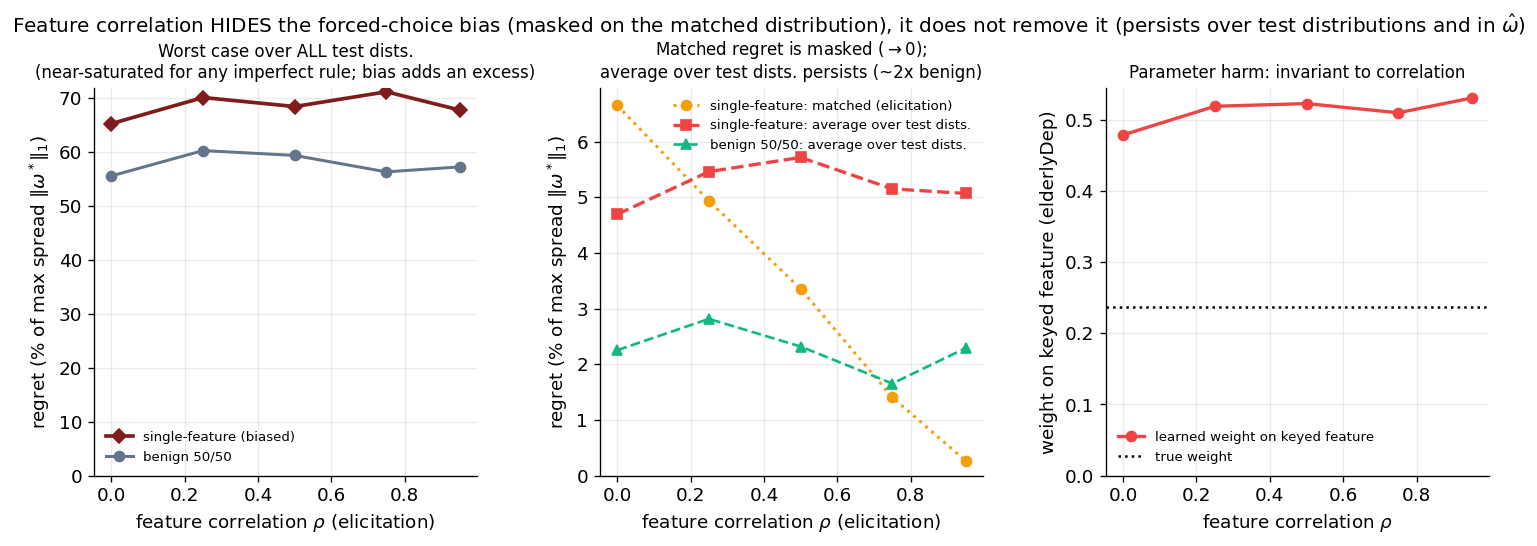

keyed-feature weight stays ~0.51 (true 0.24) for ALL rho. Matched regret -> 0.3% at rho=0.95, but AVERAGE over test dists stays ~5% (vs benign ~2%) and the WORST case over all test dists ~68% (vs benign ~58%) -- both flat in rho.


In [14]:
# ---- D. correlation masks decision harm but not parameter harm --------------------
# Downstream regret of a learned rule omega_hat, NOT tied to any one test distribution.
# All three notions below are reported as a fraction of the largest possible decision
# spread ||omega_star||_1 (the anti-optimal ceiling over the unit box [0,1]^d; = 1 on
# the simplex). This is the natural, fixed denominator when the *test distribution
# itself is the variable* -- a per-distribution ceiling would differ across shapes and
# is degenerate for the worst case (the adversarial slate is its own ceiling).

def worstcase_over_dists(omega_hat, omega_star):
    # sup over ALL input distributions on the unit box [0,1]^d of per-decision best-of-N
    # regret of rule omega_hat under omega_star, as a fraction of ||omega_star||_1.
    # A 2-item slate {a (true-best), b (rule-picked)} suffices for the worst case:
    #   max_{a,b in [0,1]^d : omega_hat.b >= omega_hat.a} omega_star.(a - b),
    # whose LP dual is the closed form below (verified against scipy.linprog):
    #   min_{lambda >= 0} sum_j |omega_star_j - lambda * omega_hat_j|.
    # g(lambda) is piecewise-linear convex; its min over lambda>=0 sits at lambda=0 or a
    # breakpoint omega_star_j / omega_hat_j. No Monte-Carlo, no chosen test shape.
    oh = np.asarray(omega_hat, float); os_ = np.asarray(omega_star, float)
    cand = [0.0] + [os_[j] / oh[j] for j in range(len(oh)) if oh[j] != 0 and os_[j] / oh[j] > 0]
    return min(np.abs(os_ - lam * oh).sum() for lam in cand) / np.abs(os_).sum()

def random_test_models(n_models, dim, rng, smin=0.25):
    # Ensemble of random test-input distributions on the unit box: each has a random
    # Gaussian-copula correlation (PSD, U[0,1] marginals) and a random per-feature scale
    # in [smin, 1] (support [0, scale_j] stays inside the box the worst case covers).
    models = []
    for _ in range(n_models):
        A = rng.normal(size=(dim, dim)); C = A @ A.T
        d = np.sqrt(np.diag(C)); corr = C / np.outer(d, d)       # random PSD correlation
        models.append((corr, rng.uniform(smin, 1.0, size=dim)))
    return models

def avgcase_over_dists(omega_hat, omega_star, models, rng):
    # Mean best-of-N regret over the test-shape ensemble, fraction of ||omega_star||_1.
    reg = [ic.best_of_n_regret(omega_hat, omega_star, rng, n_slates=300, cov=cov, scale=sc)
           for cov, sc in models]
    return float(np.mean(reg)) / float(np.abs(omega_star).sum())

RHOS = [0.0, 0.25, 0.5, 0.75, 0.95]
dcfg = dict(tau_r=TAU_R, tau_kappa=TAU_K, noise_scale=NOISE_SCALE, noise_type=NOISE_TYPE,
            T=110, n_candidates=N_CAND, n_samples=120, burn_in=60, n_holdout=400,
            n_jobs=N_JOBS, query_sigma=0.30)
O_D = ex.make_oracles(12, dim=DIM, seed=2026, alpha=ORACLE_ALPHA)
TEST_MODELS = random_test_models(24, DIM, np.random.default_rng(404))   # ensemble of test shapes

def _matched(tr, cov):  # regret on the elicitation distribution, fraction of ||w||_1
    return 100 * np.mean([ic.best_of_n_regret(t["omega_hat"], w, np.random.default_rng(700_000 + i), cov=cov)
                          / np.abs(w).sum() for i, (t, w) in enumerate(zip(tr, O_D))])
def _worst(tr):         # closed-form worst case over all test distributions
    return 100 * np.mean([worstcase_over_dists(t["omega_hat"], w) for t, w in zip(tr, O_D)])
def _avg(tr):           # average over the random ensemble of test distributions
    return 100 * np.mean([avgcase_over_dists(t["omega_hat"], w, TEST_MODELS, np.random.default_rng(710_000 + i))
                          for i, (t, w) in enumerate(zip(tr, O_D))])

# Biased single-feature(0) rule vs a benign 50/50 baseline; the benign rule is also
# evaluated worst/average over test dists, so the persistent excess is attributable to
# the bias and not to generic finite-sample estimation error.
reg_match, reg_worst, reg_avg = [], [], []          # biased single-feature
ben_avg,  ben_worst = [], []                          # benign 50/50
infl = []
for rho in RHOS:
    cov = None if rho == 0 else (1 - rho) * np.eye(DIM) + rho * np.ones((DIM, DIM))
    trs = ex.run_method({"kind": "bt", "forcing": ic.force_single_feature, "forcing_kwargs": {"feature": 0}},
                        O_D, base_seed=SEED, feature_cov=cov, **dcfg)
    trb = ex.run_method({"kind": "bt", "forcing": ic.force_5050}, O_D, base_seed=SEED, feature_cov=cov, **dcfg)
    reg_match.append(_matched(trs, cov)); reg_worst.append(_worst(trs)); reg_avg.append(_avg(trs))
    ben_worst.append(_worst(trb)); ben_avg.append(_avg(trb))
    infl.append(float(np.mean([t["omega_hat"][0] for t in trs])))
f0_true = float(np.mean([w[0] for w in O_D]))

# Worst (~60-70%) and average/matched (~0-7%) live on very different scales, so we give
# each its own panel: (1) worst case over all test dists, (2) matched vs average, (3) omega.
fig, (axW, axA, axR) = plt.subplots(1, 3, figsize=(15, 4.2))
fig.subplots_adjust(wspace=0.32)

# Panel 1: worst case over ALL test distributions (closed-form ceiling).
axW.plot(RHOS, reg_worst, "D-", color="#7f1d1d",         lw=2.2, label="single-feature (biased)")
axW.plot(RHOS, ben_worst, "o-", color=PALETTE["bt_comp"], lw=1.8, label="benign 50/50")
axW.set_xlabel(r"feature correlation $\rho$ (elicitation)")
axW.set_ylabel(r"regret (% of max spread $\|\omega^*\|_1$)")
axW.set_title("Worst case over ALL test dists.\n(near-saturated for any imperfect rule; bias adds an excess)",
              fontsize=10)
axW.legend(fontsize=8); axW.set_ylim(bottom=0)

# Panel 2: matched (masked) vs average over the test-shape ensemble.
axA.plot(RHOS, reg_match, "o:",  color="#f59e0b",          lw=1.8, label="single-feature: matched (elicitation)")
axA.plot(RHOS, reg_avg,   "s--", color=PALETTE["bt_single"], lw=2.0, label="single-feature: average over test dists.")
axA.plot(RHOS, ben_avg,   "^--", color=PALETTE["bt_5050"],  lw=1.6, label="benign 50/50: average over test dists.")
axA.set_xlabel(r"feature correlation $\rho$ (elicitation)")
axA.set_ylabel(r"regret (% of max spread $\|\omega^*\|_1$)")
axA.set_title("Matched regret is masked ($\\to 0$);\naverage over test dists. persists (~2x benign)", fontsize=10)
axA.legend(fontsize=8); axA.set_ylim(bottom=0)

# Panel 3: parameter harm -- the learned weight on the keyed feature.
axR.plot(RHOS, infl, "o-", color=PALETTE["bt_single"], lw=2, label="learned weight on keyed feature")
axR.axhline(f0_true, color="k", ls=":", lw=1.5, label="true weight")
axR.set_xlabel(r"feature correlation $\rho$"); axR.set_ylabel("weight on keyed feature (elderlyDep)")
axR.set_title("Parameter harm: invariant to correlation", fontsize=10); axR.legend(fontsize=8); axR.set_ylim(bottom=0)

fig.suptitle("Feature correlation HIDES the forced-choice bias (masked on the matched distribution), "
             "it does not remove it (persists over test distributions and in $\\hat\\omega$)",
             y=1.03, fontsize=12)
fig.savefig("fig_correlation_masking.pdf"); fig.savefig("fig_correlation_masking.png")
plt.show()
print("keyed-feature weight stays ~%.2f (true %.2f) for ALL rho. Matched regret -> %.1f%% at rho=%.2f, "
      "but AVERAGE over test dists stays ~%.0f%% (vs benign ~%.0f%%) and the WORST case over all test "
      "dists ~%.0f%% (vs benign ~%.0f%%) -- both flat in rho."
      % (np.mean(infl), f0_true, reg_match[-1], RHOS[-1], np.mean(reg_avg), np.mean(ben_avg),
         np.mean(reg_worst), np.mean(ben_worst)))


### Robustness conclusions

* **Reduction at $\tau=0$ (Block 0): fully robust.** It is an algebraic identity; it holds exactly under
  correlated and heterogeneously-scaled features (verified separately, max curve difference $=0$).
* **Broad $\gg$ binary (Block 2): fully robust.** The broad learner is correctly specified, so it
  recovers $\omega$ (regret $\approx 0$) at every $\alpha$, every query distribution, and every feature
  model tested. This claim does not depend on our choices.
* **benign $<$ feature-keyed-biased ordering (Block 1): directionally robust but magnitude-contingent.**
  The ordering holds everywhere, and it is *not* an artifact of the sparse $\alpha=0.3$ oracle (it
  persists at $\alpha=0.1$ and $1.0$). But the *size* of the gap is contingent: it needs **similar
  options** to be large (by design — that is the stimulus axis), and it **largely vanishes at the real
  kidney feature geometry, even in the average case**. Sweeping *which* attribute the heuristic keys on
  (section C): under **independent** features the bias is target-agnostic and large (single-feature
  averages ~17% of worst-case $\approx 3\times$ benign, for *any* attribute); under the **real kidney
  scales + correlation** it averages only ~6% $\approx$ benign, and *only* a heuristic fixated on the
  single highest-spread attribute (`weeklyWorkhours`) reaches ~$2\times$ benign. So the catastrophic
  magnitude is largely an artifact of the i.i.d.-feature assumption — at the geometry the kidney study
  actually exhibits, forced-choice bias is mild on average, and broad learning's advantage is the more
  robust effect.
* **But "mild decision regret" $\neq$ "no harm" — the bias is a deployment-shift liability (section D).**
  The reduced *matched* decision regret at high correlation does *not* mean the biased rule stopped
  corrupting $\hat\omega$: the learned weight on the keyed feature stays inflated at **every** $\rho$.
  Correlation only makes that distortion *irrelevant to decisions on the elicitation distribution*
  (where the weights are barely identified). To avoid pinning this on one arbitrarily-chosen off-axis
  distribution, section D measures regret two ways that do *not* depend on a test shape: the **worst
  case over all input distributions** on the unit box (a closed-form LP bound,
  $\min_{\lambda\ge0}\sum_j|\omega^*_j-\lambda\hat\omega_j|$) and the **average over a random ensemble of
  test shapes**. Both stay elevated at every $\rho$ while the matched regret collapses. So the
  safe-looking kidney numbers are conditional on deploying to a population like the elicitation one; they
  are *not* a guarantee, and any subgroup / cohort / policy that decorrelates the attributes re-exposes
  the harm — including, in the limit, the worst-case ceiling.
* **`compromise` (structural): stays $\le$ feature-keyed everywhere**, and its harmlessness is itself
  geometry-dependent (it relies on the symmetric $U[0,1]$ feature mean coinciding with the compromise
  center).

Bottom line: the most *robust* claims are the reduction and **broad $\gg$ binary** (broad recovers
$\omega$ at every setting). The **biased-forcing catastrophe is the fragile one** — it is large under
i.i.d. features but mild on average at the real kidney geometry. So for the paper, lead with the
sample-efficiency / information argument (broad observing indecision), and present forced-choice bias as
a *conditional* risk whose size depends on attribute similarity and correlation — both measurable in the
study data rather than assumed.

## Summary

1. **Reduction (Block 0).** At $\tau_r=\tau_\kappa=0$ the threshold model is ordinary binary
   Bradley–Terry: broad-response and binary learning coincide (exactly under shared randomness,
   within standard error otherwise).
2. **Biased forcing fails (Block 1).** When indecision exists and forced-choice behavior is biased,
   binary learning recovers a systematically distorted $\omega$ — weight migrates onto whatever
   feature the forcing rule keys on — and chooses worse downstream rules. Assuming
   $\tau_r=\tau_\kappa=0$ is safe *only* under benign forcing.
3. **Benign forcing wastes information (Block 2).** Even when forced labels are unbiased, observing
   indecision directly (3-way or 4-way) reaches a given weight error with fewer queries, because
   indifference and conflict constrain $r$ and $g$ in ways binary labels cannot.
4. **The failure scales with how often people are indecisive (severe regime).** Keeping the oracles,
   thresholds, and rules of Blocks 1–2 fixed and only making the options *similar* (so indecision
   dominates), biased forcing **inflates the weight of whatever feature its tiebreaker keys on** —
   roughly doubling it and tripling downstream regret — while benign forcing and broad learning are
   unaffected. The tiebreaker is orthogonal to true preference, not opposed to it; the harm comes
   from the analyst mistaking tiebreaker behavior for preference. Blocks 1–2 are the benign end of
   this same axis.

5. **Robustness (appendix).** The reduction and broad-$\gg$-binary claims are invariant to oracle
   concentration, query distribution, and feature correlation/scale. The benign-$<$-biased *ordering*
   is robust too, but the *magnitude* is contingent and **largely an artifact of the i.i.d.-feature
   assumption**: at the **empirical kidney scales + correlation** (read from the study data), averaged
   over *which* attribute the heuristic keys on, biased-forcing regret is ~benign (~6% vs ~5% of
   worst-case) — only a rule fixated on the single highest-spread attribute (workhours) reaches ~2×
   benign, vs ~3× for *any* attribute under independent features. Broad learning's advantage is the
   more robust effect. **But correlation only *masks* the bias, it does not remove it (section D):**
   evaluated as the **worst case** or the **average over test input distributions** — not on a single
   matched shape — the biased rule's downstream regret stays elevated at every $\rho$ even as its
   matched regret collapses, while its $\hat\omega$ stays inflated throughout. The bias is a latent
   deployment-shift liability.

*Figures saved:* `fig_block0_sanity.{pdf,png}`, `fig_block1_bias.{pdf,png}`, `fig_block2_efficiency.{pdf,png}`,
`fig_severe_bias.{pdf,png}`, `fig_severe_efficiency.{pdf,png}`, `fig_correlation_masking.{pdf,png}`.

*Scaling for the paper:* increase `N_ORACLES`, `T*`, and `N_SAMPLES` in the setup cell; the seed
plumbing and method definitions are unchanged.